In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [3]:
df=pd.read_csv("D:\\AshleshaRuchika\\PGCP-AI\\Machine Learning\\Datasets\\nutrient.csv",index_col=0)
df

,energy,protein,fat,calcium,iron
Food_Item,,,,,
BEEF BRAISED,340,20,28,9,2.6
HAMBURGER,245,21,17,9,2.7
BEEF ROAST,420,15,39,7,2.0
BEEF STEAK,375,19,32,9,2.6
BEEF CANNED,180,22,10,17,3.7
CHICKEN BROILED,115,20,3,8,1.4
CHICKEN CANNED,170,25,7,12,1.5
BEEF HEART,160,26,5,14,5.9
LAMB LEG ROAST,265,20,20,9,2.6


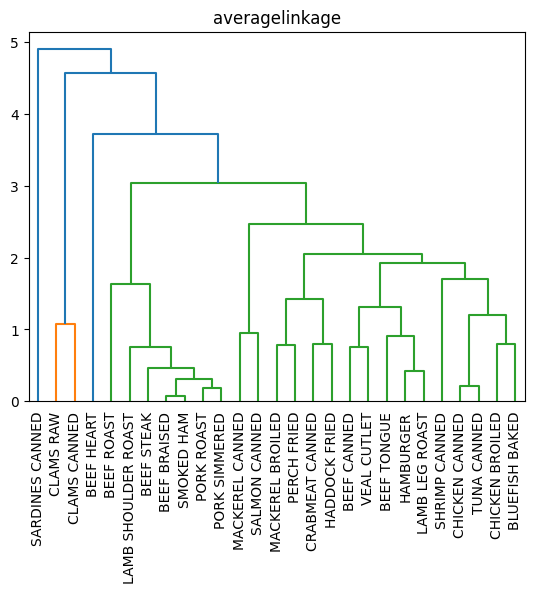

In [4]:
scaler=StandardScaler().set_output(transform='pandas')
df_scaled=scaler.fit_transform(df)
link='average'
mergings=linkage(df_scaled,method=link)
dendrogram(mergings,labels=list(df_scaled.index))
plt.title(link+'linkage')
plt.xticks(rotation=90)
plt.show()

In [5]:
Ks=[2,3,4,5]
scores=[]
for i in Ks:
    clust=AgglomerativeClustering(n_clusters=i)
    clust.fit(df_scaled)
    scores.append([i,silhouette_score(df_scaled,clust.labels_)])

df_scores=pd.DataFrame(scores,columns=['clusters','score'])
df_scores.sort_values('score',ascending=False)

,clusters,score
2,4,0.415801
1,3,0.403730
3,5,0.371724
0,2,0.325786


In [6]:
Ks=[2,3,4,5,7,6]
scores=[]
for i in Ks:
    clust=KMeans(n_clusters=i,random_state=26)
    clust.fit(df_scaled)
    scores.append([i,silhouette_score(df_scaled,clust.labels_)])
df_scores=pd.DataFrame(scores,columns=['clusters','score'])
df_scores.sort_values('score',ascending=False)

,clusters,score
3,5,0.414230
4,7,0.400601
5,6,0.381469
2,4,0.372094
1,3,0.306160
0,2,0.287596


In [7]:
from sklearn.decomposition import PCA

In [14]:
prcomp=PCA().set_output(transform="pandas")
df_scaled=scaler.fit_transform(df)
pca_data=prcomp.fit_transform(df_scaled)
km=KMeans(n_clusters=2,random_state=26)
km.fit(df_scaled)
pca_data["Cluster"]=km.labels_
pca_data["Cluster"]=pca_data["Cluster"].astype(str)

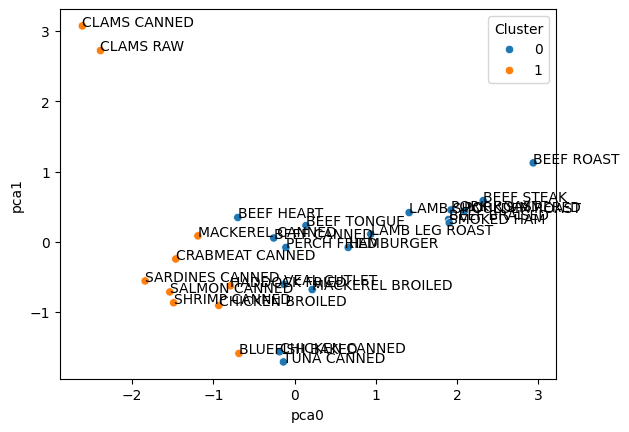

In [16]:
sns.scatterplot(data=pca_data,x="pca0",y="pca1",hue="Cluster")
for i in range(0,df.shape[0]):
    plt.text(x=pca_data["pca0"].values[i],
            y=pca_data["pca1"].values[i],
            s=list(df.index)[i])
plt.show()


## Analyzing Centroids /Cluster Analutics

In [21]:
df1=df.copy()
km=KMeans(n_clusters=5,random_state=26)
km.fit(df_scaled)
df1["Cluster"]=km.labels_
df1.groupby("Cluster").mean()

,energy,protein,fat,calcium,iron
Cluster,,,,,
0,341.875000,18.750000,28.875000,8.750000,2.437500
1,151.666667,18.333333,7.666667,227.666667,1.666667
2,164.230769,20.307692,7.923077,20.307692,1.730769
3,57.500000,9.000000,1.000000,78.000000,5.700000
4,160.000000,26.000000,5.000000,14.000000,5.900000


In [23]:
df1

,energy,protein,fat,calcium,iron,Cluster
Food_Item,,,,,,
BEEF BRAISED,340,20,28,9,2.6,0
HAMBURGER,245,21,17,9,2.7,2
BEEF ROAST,420,15,39,7,2.0,0
BEEF STEAK,375,19,32,9,2.6,0
BEEF CANNED,180,22,10,17,3.7,2
CHICKEN BROILED,115,20,3,8,1.4,2
CHICKEN CANNED,170,25,7,12,1.5,2
BEEF HEART,160,26,5,14,5.9,4
LAMB LEG ROAST,265,20,20,9,2.6,0
